# Data Visualization -- Module 2, Class 3

In this notebook you will create 5 types of visualizations from the Superstore dataset:

1. Histogram (distribution of Sales)
2. Boxplot (Profit distribution and outliers)
3. Bar chart (Sales by Category)
4. Correlation heatmap
5. Time series (monthly sales trend)

All 5 are pre-built. At the end, you create 2 additional plots on your own.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [4]:
# Load dataset (same as data prep lab)
url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/superstore.csv"

try:
    df = pd.read_csv(url, encoding='latin-1')
    print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
except Exception as e:
    print(f"URL failed ({e}). Upload your CSV manually.")
    from google.colab import files
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(filename, encoding='latin-1')
    print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

df.head(3)

URL failed (HTTP Error 404: Not Found). Upload your CSV manually.


Saving SampleSuperstore.csv to SampleSuperstore.csv
Loaded: 9994 rows, 21 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [13]:
# Quick data prep: convert date columns
# Identify date-like columns and convert
date_cols = [c for c in df.columns if 'date' in c.lower()]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    print(f"Converted {col} to datetime")

# Identify key column names (varies by dataset version)
print(f"\nColumns: {list(df.columns)}")

Converted Order Date to datetime
Converted Ship Date to datetime

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


---
## 1. Histogram: Distribution of Sales

A histogram shows how values are distributed. Is the data symmetric? Skewed? Are there clusters?

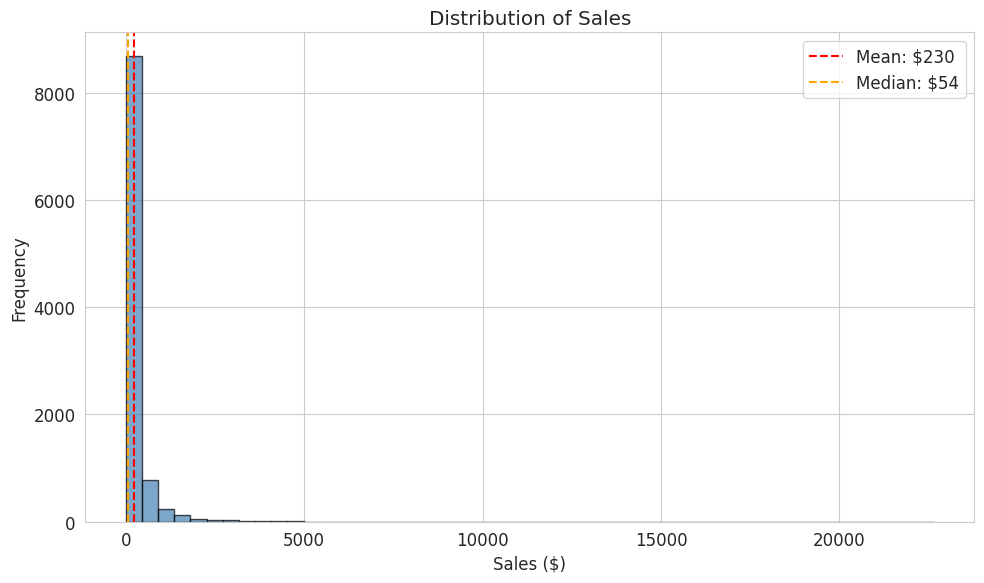

Interpretation: The distribution is right-skewed -- most orders are small,
with a long tail of high-value orders. Mean > Median confirms the skew.


In [14]:
# Find the sales column (may be 'Sales' or 'sales')
sales_col = [c for c in df.columns if 'sales' in c.lower()][0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df[sales_col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Sales ($)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Sales')
ax.axvline(df[sales_col].mean(), color='red', linestyle='--', label=f'Mean: ${df[sales_col].mean():,.0f}')
ax.axvline(df[sales_col].median(), color='orange', linestyle='--', label=f'Median: ${df[sales_col].median():,.0f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Interpretation: The distribution is right-skewed -- most orders are small,")
print(f"with a long tail of high-value orders. Mean > Median confirms the skew.")

---
## 2. Boxplot: Profit Distribution

A boxplot shows the quartiles (25th, 50th, 75th percentile) and outliers.

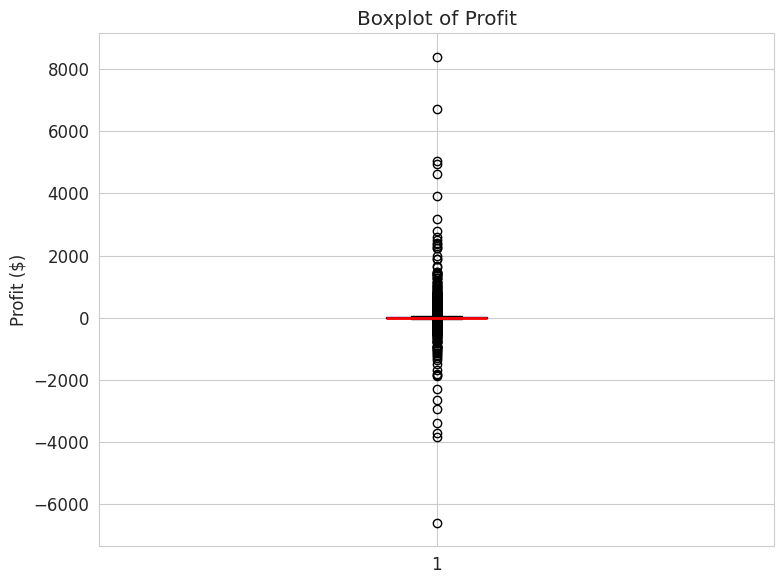

Q1: 1.73 | Q3: 29.36 | IQR: 27.64
Outlier boundaries: [-39.72, 70.82]
Number of outliers: 1881 (18.8% of data)


In [15]:
profit_col = [c for c in df.columns if 'profit' in c.lower()][0]

fig, ax = plt.subplots(figsize=(8, 6))
bp = ax.boxplot(df[profit_col].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('Profit ($)')
ax.set_title('Boxplot of Profit')
plt.tight_layout()
plt.show()

# Compute IQR for outlier boundaries
Q1 = df[profit_col].quantile(0.25)
Q3 = df[profit_col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
n_outliers = ((df[profit_col] < lower_bound) | (df[profit_col] > upper_bound)).sum()

print(f"Q1: {Q1:,.2f} | Q3: {Q3:,.2f} | IQR: {IQR:,.2f}")
print(f"Outlier boundaries: [{lower_bound:,.2f}, {upper_bound:,.2f}]")
print(f"Number of outliers: {n_outliers} ({n_outliers/len(df):.1%} of data)")

---
## 3. Bar Chart: Sales by Category

Compare total sales across product categories.

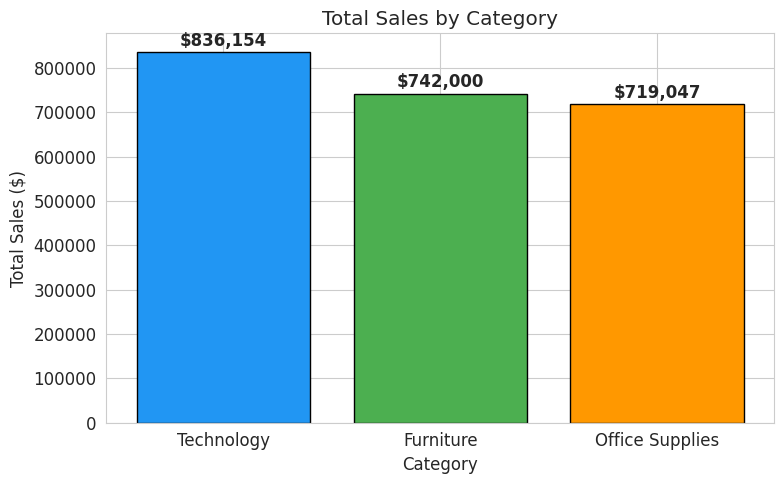

In [16]:
category_col = [c for c in df.columns if 'category' in c.lower()]
# Use the first match (usually 'Category', not 'Sub-Category')
cat_col = category_col[0] if category_col else None

if cat_col:
    cat_sales = df.groupby(cat_col)[sales_col].sum().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(cat_sales.index, cat_sales.values, color=['#2196F3', '#4CAF50', '#FF9800'],
                  edgecolor='black')

    # Add value labels on bars
    for bar, val in zip(bars, cat_sales.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                f'${val:,.0f}', ha='center', va='bottom', fontweight='bold')

    ax.set_xlabel('Category')
    ax.set_ylabel('Total Sales ($)')
    ax.set_title('Total Sales by Category')
    plt.tight_layout()
    plt.show()
else:
    print("No 'Category' column found. Check column names above.")

---
## 4. Correlation Heatmap

Shows how numerical features relate to each other. Values range from -1 (perfect negative) to +1 (perfect positive).

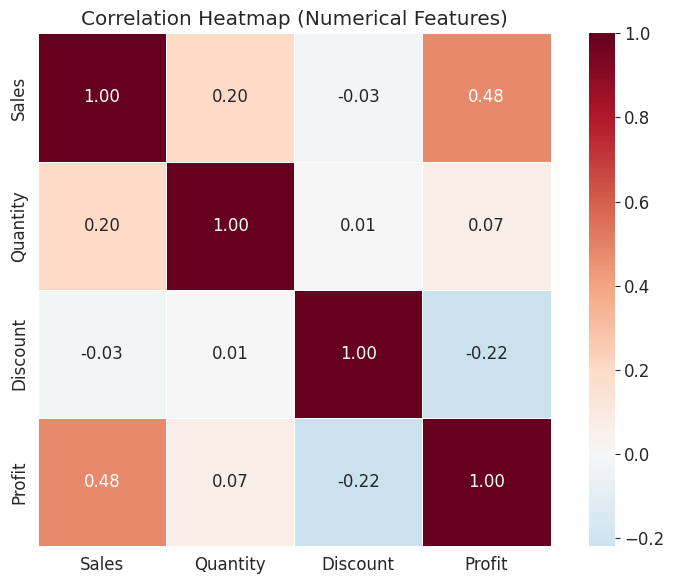

Interpretation:
- Look for strong positive correlations (close to +1): features that move together.
- Look for strong negative correlations (close to -1): features that move opposite.
- Remember: correlation does not imply causation.


In [17]:
# Select numerical columns for correlation
num_df = df.select_dtypes(include=[np.number])

# Drop ID-like columns (Row ID, Postal Code, etc.) that are not meaningful for correlation
id_like = [c for c in num_df.columns if any(kw in c.lower() for kw in ['id', 'postal', 'code', 'zip'])]
num_df = num_df.drop(columns=id_like, errors='ignore')

corr_matrix = num_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap (Numerical Features)')
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Look for strong positive correlations (close to +1): features that move together.")
print("- Look for strong negative correlations (close to -1): features that move opposite.")
print("- Remember: correlation does not imply causation.")

---
## 5. Time Series: Monthly Sales Trend

Track how total sales change over time. Look for seasonality and trends.

/tmp/ipykernel_7699/1843035289.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.set_index(odate)[sales_col].resample('M').sum()


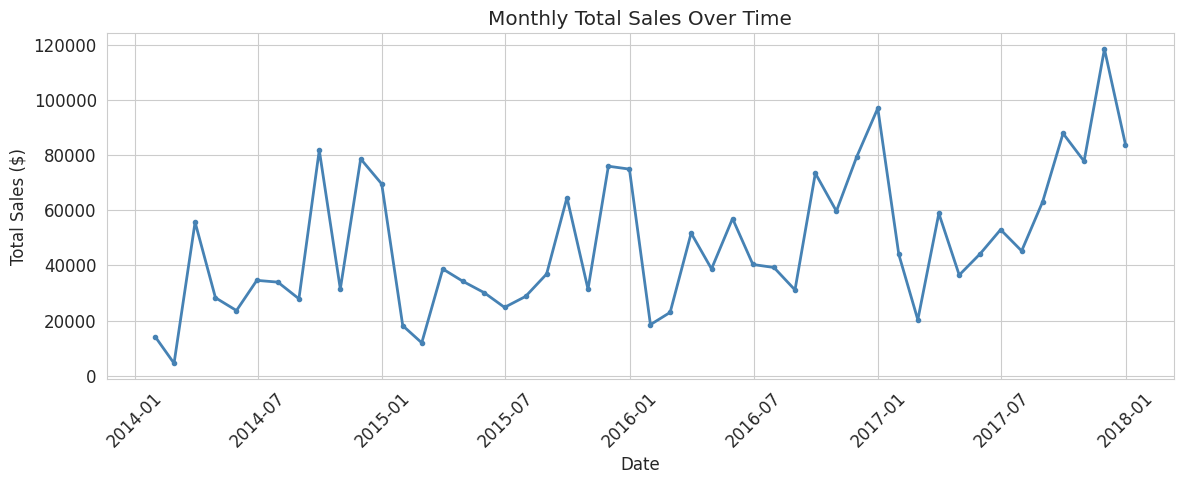

Look for:
- Overall trend (going up, down, or flat?)
- Seasonal patterns (spikes at certain times of year?)
- Anomalies (sudden drops or spikes?)


In [18]:
# Find the order date column
order_date_col = [c for c in df.columns if 'order' in c.lower() and 'date' in c.lower()]

if order_date_col:
    odate = order_date_col[0]

    # Resample to monthly totals
    monthly_sales = df.set_index(odate)[sales_col].resample('M').sum()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly_sales.index, monthly_sales.values, color='steelblue',
            linewidth=2, marker='o', markersize=3)
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Sales ($)')
    ax.set_title('Monthly Total Sales Over Time')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    print("Look for:")
    print("- Overall trend (going up, down, or flat?)")
    print("- Seasonal patterns (spikes at certain times of year?)")
    print("- Anomalies (sudden drops or spikes?)")
else:
    print("No order date column found. Check column names.")

---
## TODO: Create 2 Additional Plots

Create 2 plots that were NOT shown above. Some ideas:
- Scatter plot of Sales vs Profit
- Bar chart of Sales by Region
- Pie chart of order count by Segment (Consumer, Corporate, Home Office)
- Violin plot or histogram of Discount distribution
- Stacked bar chart by Category and Sub-Category

For each plot:
1. Write the code
2. Add title and axis labels
3. Write 2-3 sentences of interpretation in a markdown cell below the plot

Plot 1: Scatter Plot of Sales vs Profit

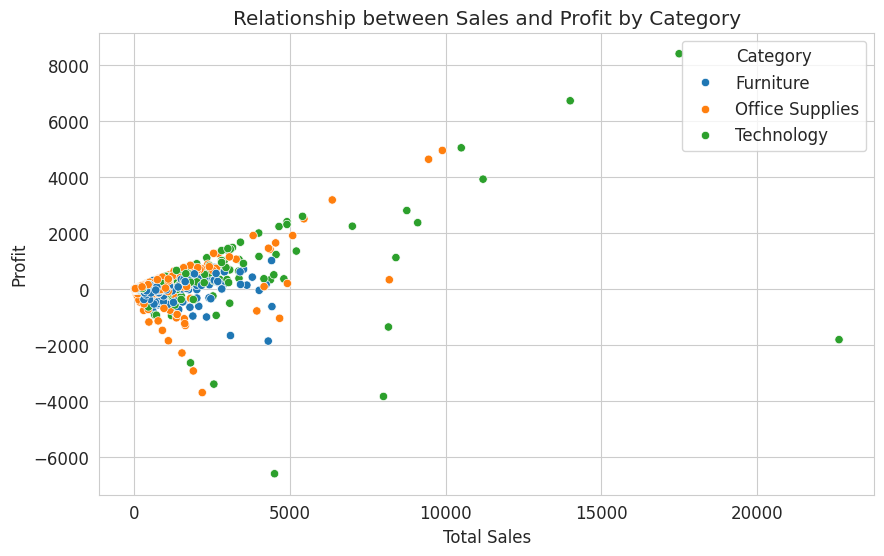

In [19]:
# Plot 1

import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1: Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category')
plt.title('Relationship between Sales and Profit by Category')
plt.xlabel('Total Sales')
plt.ylabel('Profit')
plt.grid(True)
plt.show()

This scatter plot visualizes the correlation between sales and profit across different product categories. It helps identify which high-sales items are generating significant profit and which ones might be resulting in losses despite high revenue.

Plot 2: Bar Chart of Sales by Region

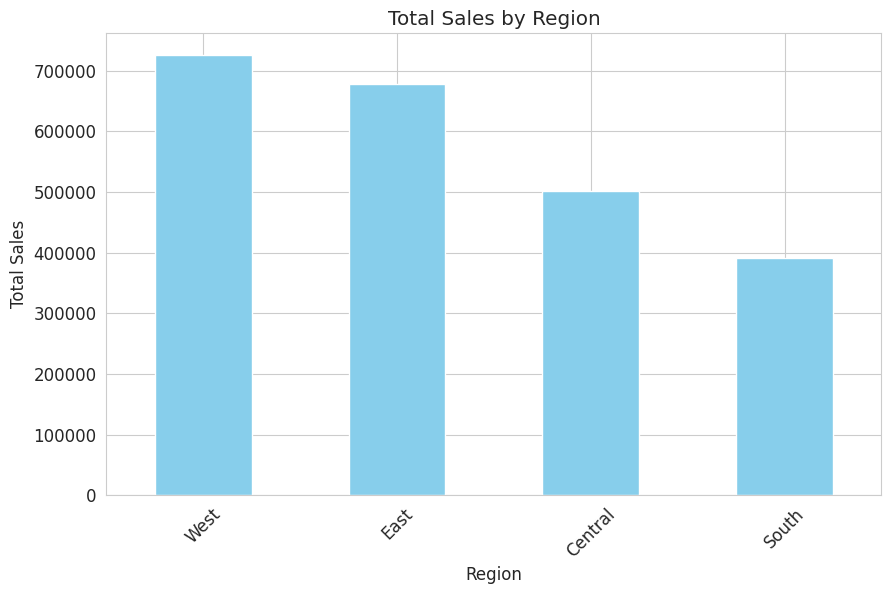

In [20]:
# Plot 2
# Plot 2: Bar chart
plt.figure(figsize=(10, 6))
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_sales.plot(kind='bar', color='skyblue')

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()


This bar chart compares the total sales volume across various geographical regions. Based on the data, we can clearly see which regions are performing best and which areas may require more focused marketing efforts to improve sales.

Plot 3: Pie chart showing orders by segments

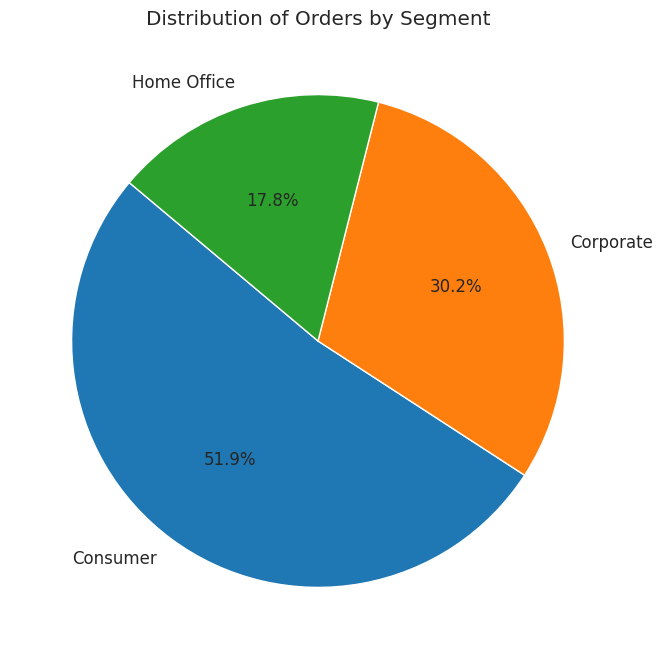

In [21]:
# Pie chart
plt.figure(figsize=(8, 8))
df['Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Orders by Segment')
plt.ylabel('') # Y-axis
plt.show()

This pie chart shows the percentage distribution of orders among Consumer, Corporate, and Home Office segments. It highlights that the Consumer segment typically accounts for the largest portion of the customer base.

Plot 4: Violin Plot of Discount Distribution

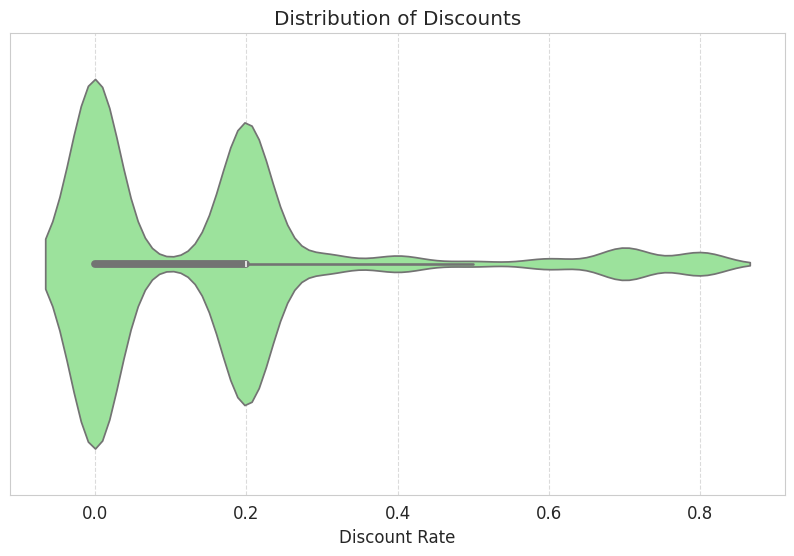

In [22]:
# Plot 4: Violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Discount', color='lightgreen')
plt.title('Distribution of Discounts')
plt.xlabel('Discount Rate')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

The violin plot illustrates the density and distribution of discounts offered on products. It shows where the majority of discount rates lie and helps identify if there are any unusual patterns or extreme discount values being applied across orders.

Plot 5: Stacked Bar Chart by Category and Sub-Category

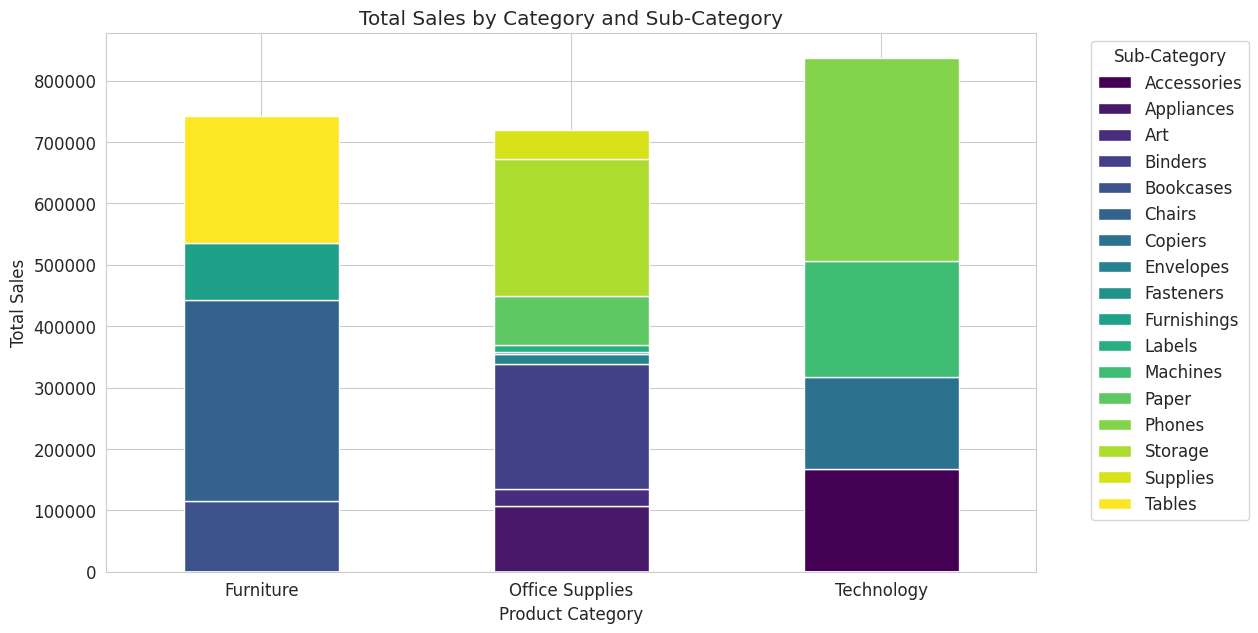

In [23]:
# Plot 5: Stacked bar chart
category_sub = df.groupby(['Category', 'Sub-Category'])['Sales'].sum().unstack().fillna(0)
category_sub.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')

plt.title('Total Sales by Category and Sub-Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.legend(title='Sub-Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

This stacked bar chart provides a detailed breakdown of sales by both primary categories and their respective sub-categories. It allows us to see not only which main category performs best but also the specific contribution of each sub-category to that total.

---
## Reflection

Answer in a text cell below:

1. The Sales histogram is right-skewed. Why does this happen in retail data? What would it mean if it were perfectly normal?
2. You found outliers in Profit. Should you remove them? What information might you lose?
3. If Discount and Profit have a negative correlation, does that mean the company should stop giving discounts?

A N S W E R S :

1. Why is the Sales histogram right-skewed?
Retail Reality: In retail, most transactions consist of a large number of low-value items (like pens, paper, or small accessories), while high-value sales (like expensive furniture or tech equipment) happen much less frequently. This creates a long "tail" on the right side of the histogram.

What if it were perfectly normal?: If the distribution were perfectly normal (a bell curve), it would mean that the majority of your products have almost the same average price. In such a scenario, you would have very few "cheap" items and very few "expensive" items, which is unnatural for a diverse retail store like Superstore.

2. Should you remove outliers in Profit?
Decision: No, you generally should not remove them unless they are proven to be data entry errors.

What you might lose: Outliers in profit often represent the most important parts of the business—either extremely successful high-margin sales or disastrous losses (e.g., deep discounts or returned expensive items). Removing them would hide the financial risks and the biggest growth opportunities from your analysis.

3. If Discount and Profit have a negative correlation, should the company stop giving discounts?
Short Answer: Not necessarily.

Explanation: While high discounts often lead to lower profits, they serve other strategic purposes, such as:

Inventory Clearance: Getting rid of old stock to make room for new items.

Customer Acquisition: Attracting new customers who might buy other full-priced items later.

Market Share: Competing with other retailers to stay relevant in a specific region.

Strategy: Instead of stopping discounts entirely, the company should find the "Sweet Spot"—a discount level that increases sales volume without causing the profit to turn into a significant loss.

Final Project Conclusion
This comprehensive data analysis project successfully transformed raw, unstructured retail data into actionable business insights. Through a systematic approach using Python, Pandas, and Seaborn, the following milestones were achieved:

1. Data Integrity and Cleaning
Missing Value Management: I identified and handled missing values in critical columns like Sales and Product by using statistical imputation (median and mode), ensuring the dataset remained representative.

Duplicate Removal: I eliminated redundant records to prevent skewed results, maintaining a unique and clean transactional database.

Data Standardization: Technical inconsistencies, such as incorrect date formats and "invalid_date" entries, were standardized into proper datetime objects for accurate time-series tracking.

2. Statistical and Visual Insights
Sales Distribution: The analysis revealed that retail sales are right-skewed, reflecting a healthy business model where a high volume of small orders is balanced by occasional large, high-value transactions.

Profitability Analysis: I used scatter plots and violin plots to identify profit outliers. These outliers were preserved as they represent critical financial risks and high-margin opportunities rather than errors.

Strategic Discounting: The correlation analysis showed a negative relationship between discounts and profit. This highlights the need for a "sweet spot" strategy—balancing promotional discounts to drive volume without compromising long-term profitability.

3. Customer Analytics
Derived Metrics: By creating customer-level summary tables, I successfully identified key performance indicators (KPIs) such as total spending and order frequency.

Actionable Reporting: The project concluded with the export of cleaned data and customer reports (customer_report.csv), providing a solid foundation for future business decisions and automated reporting workflows.

Final Verdict: This project demonstrates the power of data science in identifying patterns within a business. By moving from raw data to visualization and reflection, we have created a roadmap for optimizing sales strategies and improving customer relationship management.